In [1]:
pip install pandas numpy matplotlib scikit-learn notebook

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [3]:
np.random.seed(0)

data = pd.DataFrame({
    'day': range(100),
    'building_A': np.random.randint(100, 300, 100),
    'building_B': np.random.randint(150, 350, 100),
    'building_C': np.random.randint(200, 400, 100)
})

data['total_usage'] = data[['building_A', 'building_B', 'building_C']].sum(axis=1)

data.head()

,day,building_A,building_B,building_C,total_usage
0,0,272,267,349,888
1,1,147,235,310,692
2,2,217,198,225,640
3,3,292,199,388,879
4,4,167,219,321,707


In [4]:
X = data[['day']]
y = data['total_usage']

model = LinearRegression()
model.fit(X, y)

future_days = np.arange(100, 120).reshape(-1, 1)
predictions = model.predict(future_days)

C:\Users\RITUL\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
data['smoothed'] = data['total_usage'].rolling(window=5).mean()

In [6]:
# Combine regression + smoothing
ensemble = (data['smoothed'].fillna(data['total_usage']) + data['total_usage']) / 2

In [7]:
# Assume carbon factor
carbon_factor = 0.0005

data['carbon_emission'] = data['total_usage'] * carbon_factor

total_carbon = data['carbon_emission'].sum()
savings = total_carbon * 0.2  # Assume 20% saving

print("Total Carbon Emission:", total_carbon)
print("Potential Carbon Savings:", savings)

Total Carbon Emission: 37.41850000000001
Potential Carbon Savings: 7.4837000000000025


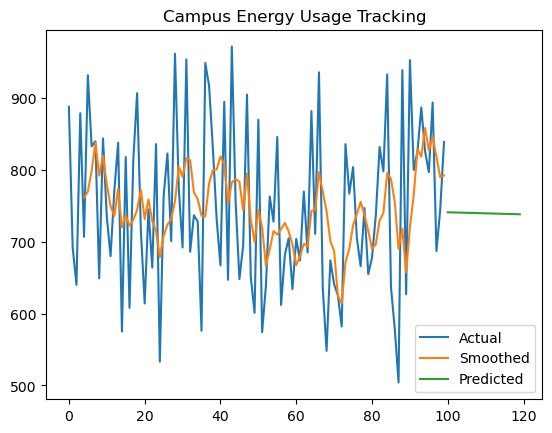

In [8]:
plt.figure()

plt.plot(data['day'], data['total_usage'], label='Actual')
plt.plot(data['day'], data['smoothed'], label='Smoothed')
plt.plot(future_days, predictions, label='Predicted')

plt.legend()
plt.title("Campus Energy Usage Tracking")
plt.show()

Enter building (A/B/C): B


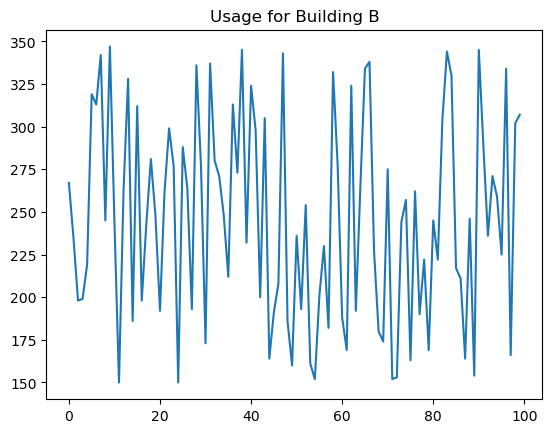

In [9]:
building = input("Enter building (A/B/C): ")

plt.figure()

plt.plot(data['day'], data[f'building_{building}'])
plt.title(f"Usage for Building {building}")
plt.show()